# Single-Stock Return Analysis - Meta Plafroms (2012-2026)

**Question:** What do the return, volatility, and drawdown characteristics of a single large-cap equity look like - and how far do they depart from the normal distribution assumed by introductory models? 

**Data:** Yahoo Finance daily prices via 'yfinance' ('auto_adjust=True', so splits and dividends are folded in - daily percent change approximates a total return).
Downloaded once and cahed to 'data/'; the analysis reads from disk.

**Author:** Alexandre • [Github](https://github.com/alexandret-11) • [LinkedIn](https://linkedin.com/in/alexandrethompson)

---
*Project 1 of a 7-projext quantitative research portfolio. Next: multi-asset comparison and correlation structure*

## Setup

Interim data source qhile WRDS/CRSP access is pending. The pull is isolated in a singkle cell so that the data layer can be swapped for CRSP later without touching any analysis code.

## Data

One network call, then cached. Two data-handling detials worth flagging: newer 'yfinance' versions return two-level columns (flattened at the boundary below), and the first row's return is 'NaN by construction - a series of *n* prices yields *n-1* returns.

In [2]:
# Block 0 - Data Pull(Yahoo Finance)
# Interim source while WRDS summer access is pending

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# auto_adjust=True -> closes adjusted for splits AND dividends, so pct_change
# approximates a total return
raw = yf.download(
    "META",
    start="2012-05-18",  # IPO date
    auto_adjust=True,
    progress=False,
)

# Newer yfinance returns MultiIndex columns (built for multi-ticker calls);
# flatten so raw["Close"] works across versions
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

# .copy() serves df from raw -> avoids SettingWithCopyWarning on assignment
df = raw[["Close"]].rename(columns={"Close": "px_adj"}).copy()
df["ret"] = df["px_adj"].pct_change()
df.to_csv("../data/meta_prices_yf.csv")

# Four Diagnostic Tests
print(df.shape)
print(df.head(3))
print(df.tail(3))
print(df["ret"].isna().sum())

(3589, 2)
Price          px_adj       ret
Date                           
2012-05-18  37.897205       NaN
2012-05-21  33.733768 -0.109861
2012-05-22  30.730143 -0.089039
Price           px_adj       ret
Date                            
2026-08-25  570.049988  0.019731
2026-08-26  576.140015  0.010683
2026-08-27  571.099976 -0.008748
1


In [3]:
df["log"] = np.log(df["px_adj"]).diff()

print(df[["ret", "log"]].describe())

gap = (df["ret"] - df["log"]).abs()
print(df.loc[gap.nlargest(5).index, ["ret", "log"]])

print(
    f"Worst day: {df['ret'].idxmin().date()} "
    f"simple {df['ret'].min():.2%}, "
    f"log {df['log'].min():.2%}"
)

Price          ret          log
count  3588.000000  3588.000000
mean      0.001071     0.000756
std       0.025108     0.025112
min      -0.263901    -0.306391
25%      -0.010191    -0.010243
50%       0.000959     0.000959
75%       0.012693     0.012613
max       0.296115     0.259371
Price            ret       log
Date                          
2022-02-03 -0.263901 -0.306391
2013-07-25  0.296115  0.259371
2022-10-27 -0.245571 -0.281794
2023-02-02  0.232824  0.209308
2018-07-26 -0.189609 -0.210239
Worst day: 2022-02-03 simple -26.39%, log -30.64%


### Figure 1: The Price Path 

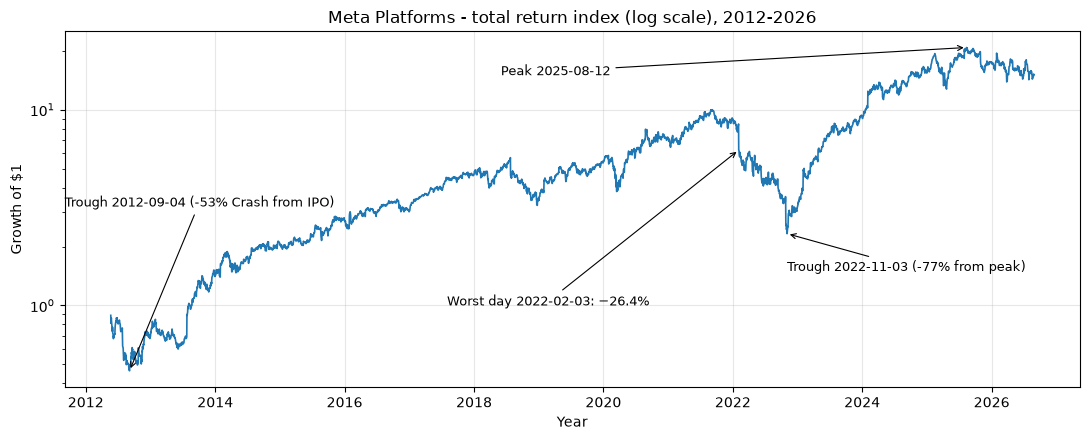

In [4]:
r = df["ret"].dropna()
tri = (1 + r).cumprod()  # total return index, starts at ~1

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(tri.index, tri.values, lw=1.2)
ax.set_yscale("log")
ax.set_title("Meta Platforms - total return index (log scale), 2012-2026")
ax.set_xlabel("Year")
ax.set_ylabel("Growth of $1")
ax.grid(alpha=0.3)
plt.tight_layout()

# --- annotations: peak, trough, worst single day ---
peak_dt = tri.loc["2012":"2026"].idxmax()
trough1_dt = tri.loc["2012":"2026"].idxmin()
trough2_dt = tri.loc["2022":"2026"].idxmin()
crash_dt = pd.Timestamp("2012-02-03")

ax.annotate(
    f"Peak {peak_dt.date()}",
    xy=(peak_dt, tri[peak_dt]),
    xytext=(pd.Timestamp("2018-06-01"), 15),
    arrowprops=dict(arrowstyle="->", lw=0.8),
    fontsize=9,
)

ax.annotate(
    f"Trough {trough1_dt.date()} (-53% Crash from IPO)",
    xy=(trough1_dt, tri[trough1_dt]),
    xytext=(pd.Timestamp("2011-09-04"), 3.2),
    arrowprops=dict(arrowstyle="->", lw=0.8),
    fontsize=9,
)

ax.annotate(
    f"Trough {trough2_dt.date()} (-77% from peak)",
    xy=(trough2_dt, tri[trough2_dt]),
    xytext=(pd.Timestamp("2022-11-03"), 1.5),
    arrowprops=dict(arrowstyle="->", lw=0.8),
    fontsize=9,
)

crash_dt = df["ret"].idxmin()

ax.annotate(
    f"Worst day {crash_dt.date()}: −{abs(df['ret'].min()):.1%}",
    xy=(crash_dt, tri[crash_dt]),
    xytext=(pd.Timestamp("2017-08-01"), 1),
    arrowprops=dict(arrowstyle="->", lw=0.8),
    fontsize=9,
)

fig.savefig("../output/fig1_total_return_index.png", dpi=150, bbox_inches="tight")


### The Story Behind the Price

1. **The IPO crash (May-September 2012).** Meta's first months aas a public compay were a disaster: from the $38 IPO price, teh stock fell roughly 53% to its September 2012 bottom, weighed down by a botched NASDAQ opening and doubts about mobile advertising revenue. The chart opens with a crisis.

2. **The long climb(2013-2021).** As mobile ad revenue provedout, teh stock componded for nearly a decade - punctuated by sharp but temporary dripos in 2018 (Cambridge Analytica and a -19% day in July 2018) and the COVID crash of March 2020 - reaching its peak on September 7, 20201.

3. **The collapse (September 2021 - NOvember 2022).** The decline began with Apple's IPS privacy changes cutting ad targeting, then accelerated on February 3, 2022, when a weak earnings report and heavy Metaverse spending drove a −26.4% single day — at the time, the largest one-day loss of market
value in US history, over $230B ([CNBC](https://www.cnbc.com/2022/02/03/facebooks-232billion-drop-in-value-sets-all-time-record.html)), 
a record later surpassed by Nvidia's $589B loss in January 2025
([CNBC](https://www.cnbc.com/2025/01/27/nvidia-sheds-almost-600-billion-in-market-cap-biggest-drop-ever.html)). The slide continued to a trough on November 4, 2022: roughly -77% from peak, in about 14 months.

4. **The recvovcer (2023-present).** From the trough, a cost-cutting program (the "year of efficiency"), a rebound in ad revenue, and AI momentum drove one of the sharpest recoveries by a mega-cap: the stock regained its prior peak in early 2024 and has since gone well above it - teh total return index ends near 14.5x the IPO-day dollar.

### Figure 2 - the distribution, and the four moments

mean daily 0.00107
std daily 0.02511
skew 0.413
excess kurt 19.310
SignificanceResult(statistic=np.float64(55845.15124997676), pvalue=np.float64(0.0))
days beyond ±4σ: observed 23, normal predicts 0.23


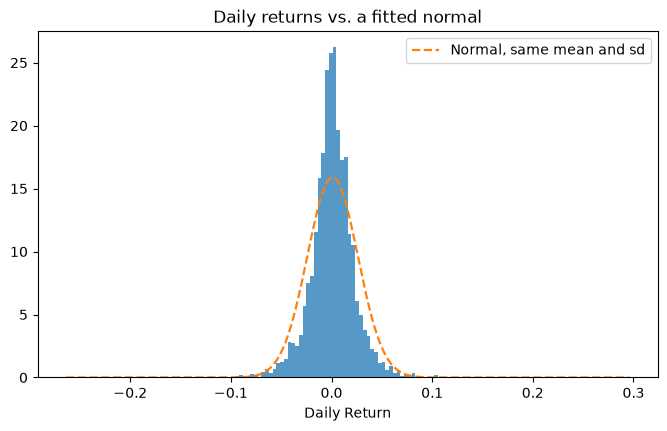

In [5]:
mu, sd = r.mean(), r.std()
print(f"mean daily {mu:.5f}")
print(f"std daily {sd:.5f}")
print(f"skew {stats.skew(r):.3f}")
print(f"excess kurt {stats.kurtosis(r):.3f}")  # 0 = normal
print(stats.jarque_bera(r))  # bigger = less normal

# Figure 2 - Historgram

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(r, bins=150, density=True, alpha=0.75)
x = np.linspace(r.min(), r.max(), 500)
ax.plot(x, stats.norm.pdf(x, mu, sd), lw=1.6, ls="--", label="Normal, same mean and sd")
ax.set_title("Daily returns vs. a fitted normal")
ax.set_xlabel("Daily Return")
ax.legend()


# Exceedence Count
z = (r - mu) / sd
observed = (z.abs() > 4).sum()
expected = 2 * (1 - stats.norm.cdf(4)) * len(r)
print(f"days beyond ±4σ: observed {observed}, normal predicts {expected:.2f}")


### The Story Behind the Distribution: 
1. **Too many quiet days, far too many wild ones.** The historgram towers over the fitted normal at the centre and escapes it entirely in the tails: most days cluster tightly near zero, while the sample contains 23 days beyond ±4 standard deviations - a normal dsitribution predicts 0.23 in a sample this size(3,584 days), a 100x exceedence. Excess kurtosis of 19.3 (normal = 0) says the same thing numerically: the distribution is strongly **leptokurtic** - heavy-tailed, with far more probablilty mass in extreme oitcomes than a Gaussian allows,.

2. **The skew surprise** We expected a negative skew - equities typically crash harder than they rally, and META's -26% (Feb 2022) and -19% (Jul 2018) days fit this pattern. Instead skew is **+0.41**: Meta's post-earnings *surges* (+30% in Jul, +23% in Feb 2023, +21% in Feb 2024)have been as extreme as its collapses. The violence runs in both directions.

3. **Formally:** Jarque-Bera = 55,731 (p=0) rejects normality - though at n = 3,584 this is unsurprising for any real return series; the moments and exceedence count carry the substance.

Daily returns are strongly leptokurtic; the Gaussian, which mandates zero excess kurtosis, is structurally incapable of describing them — and the failure is worst in the tails, which is where risk management actually happens.

### Figure 3: Volatility and Why √252

annualized vol 39.86%
0.07025244034794059
2017-04-13 00:00:00
0.9656270301643525
2022-12-06 00:00:00


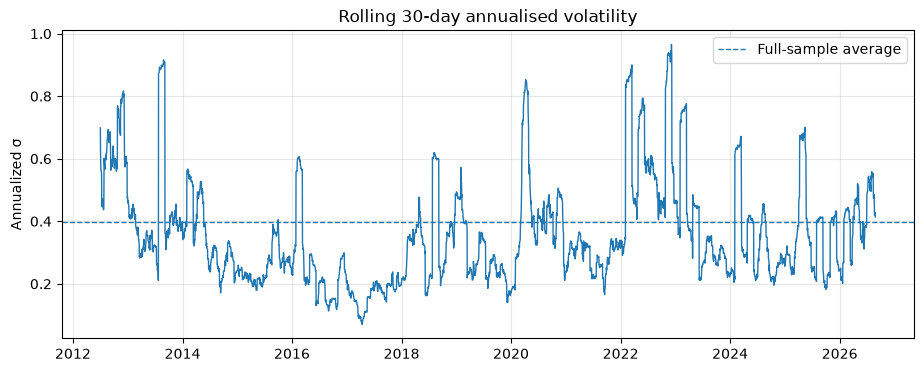

In [6]:
ann_vol = r.std() * np.sqrt(252)
print(f"annualized vol {ann_vol:.2%}")

roll = r.rolling(30).std() * np.sqrt(252)
# Test
roll_short = r.rolling(10).std() * np.sqrt(252)
roll_long = r.rolling(250).std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(roll.index, roll.values, lw=1)
# ax.plot(roll_short.index, roll_short.values, lw=0.5)
# ax.plot(roll_long.index, roll_long.values, lw=0.5)
ax.axhline(ann_vol, ls="--", lw=1, label="Full-sample average")
ax.set_title("Rolling 30-day annualised volatility")
ax.set_ylabel("Annualized σ")
ax.legend()
ax.grid(alpha=0.3)


print(roll.min())
print(roll.idxmin())
print(roll.max())
print(roll.idxmax())


In [8]:
spy = yf.download("SPY", start="2012-05-18", auto_adjust=True, progress=False)
if isinstance(spy.columns, pd.MultiIndex):
    spy.columns = spy.columns.get_level_values(0)
spy_vol = spy["Close"].pct_change().std() * np.sqrt(252)
print(f"SPY annualised vol, same window: {spy_vol:.1%}")

SPY annualised vol, same window: 16.7%


### The Story behind the volatility 

1. **One number, fourteen years, almost no overlap.** Full-sample annualised volatility is 39.9% — high even by single-stock standards (large-cap names typically run ~25–35%; the S P 500 index, where individual shocks partly cancel through diversification, ~15–20%)(16.7% during the same timeframe.). But the rolling 30-day estimate ranged from **7%** (window ending Apr 2017) — briefly calmer than the index itself — to **97%** (window ending Dec 2022), wilder than the index in all but its worst crisis weeks. A 14× spread: the "average" describes almost no actual period.

2. **Volatility Clusters.** If daily returns were independent - the assumption behind the √252 annualisation - the rolling line would wander randomly around its average. Instead it shows regimes: long quiet plateaus (2016-2017), then eruptions that persist for months. Calm follows calm; storms follow storms. This is the most robust empirical regularity in asset return, and it is why GARCH-family model exists.

3. **The peak wasn't the crash - it was the turn.** The stormiest window ends 6 Dec 2022, spanning the November trough - not the February collapse that started the decline. The mechanism: volatility measures day-to-day disagreement, not bad news. February was one enormous repricing inside an otherwise orderly window; late October-November was capitulation - the Oct 27 earnings collapse (-24.6%), forced and despairing selling into teh Nov 4 bottom, then the first violent recovery rallies as exhaust supply met retuning buyers. Many large moves in both directions out-storm one giant move in one direction. Turning points, where uncertainty about *dircetion* is maximal, are where variance peaks - declines merely trend.

4. **Estimator honesty.** Single-day shocks (Feb 2022's -26%) inflate the 30-day window for exactly 30 trading days and then fall out of it - the near-rectangular plateaus after each famous crash are an artifact of the window, not a property of the market. Window length (here 30 days) trades noise against responsiveness; teh regime pattern survives any resaonanle choice.

## References

**Data:** Yahoo Finance daily prices, retrieved via the `yfinance` Python package
(auto_adjust=True). All return, volatility, and drawdown figures are computed
in this notebook from that data.

**Narrative sources:**
1. CNBC — "Facebook's $232 billion fall sets record for largest one-day value
   drop in stock market history" (Feb 3, 2022).
   https://www.cnbc.com/2022/02/03/facebooks-232billion-drop-in-value-sets-all-time-record.html
2. CNBC — "Nvidia sheds almost $600 billion in market cap, biggest one-day loss
   in U.S. history" (Jan 27, 2025).
   https://www.cnbc.com/2025/01/27/nvidia-sheds-almost-600-billion-in-market-cap-biggest-drop-ever.html
3. Bloomberg — "Facebook's $119 Billion One-Day Rout Makes U.S. History"
   (Jul 26, 2018).
   https://www.bloomberg.com/news/articles/2018-07-26/facebook-s-119-billion-one-day-rout-makes-u-s-history-chart
4. CNBC — "Facebook's IPO 10 years later" (May 18, 2022) — post-IPO decline of
   roughly half within three months.
   https://www.cnbc.com/2022/05/18/facebook-ipo-10-years-later-new-name-same-ceo-familiar-problem.html
5. Krigman & Jeffus, "IPO pricing as a function of your investment banks' past
   mistakes: The case of Facebook," *Journal of Corporate Finance* (2016) —
   IPO mechanics; $17.73 close on Sep 4, 2012.
   https://www.sciencedirect.com/science/article/abs/pii/S0929119916300190